## Finetuned Model Post-Processing

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# ==== USER INPUT HERE ====
RUN_ID = 732620  # 731507

out_file = f"mace_{str(RUN_ID)}.out"
err_file = f"mace_{str(RUN_ID)}.err"
train_script = f"train_{str(RUN_ID)}.sbatch"

In [26]:
# load in job.out generated by training run

pattern = re.compile(
    r"(?:Epoch (\d+)|(Initial)): head: (\S+), loss=([\d.]+), "
    r"RMSE_E_per_atom=\s*([\d.]+) meV, "
    r"RMSE_F=\s*([\d.]+) meV / A, "
    r"RMSE_stress=\s*([\d.]+) meV / A\^3"
)

with open(f"../logs/{out_file}", "r") as f:
    log_out = f.read()

matches = pattern.findall(log_out)

rows = [
    (epoch_num if epoch_num else "-1", *rest)
    for epoch_num, _initial, *rest in matches
]

# make dataframe of epoch readouts
df = pd.DataFrame(
    rows,
    columns=["epoch", "head", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
)

numeric_cols = ["epoch", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
df[numeric_cols] = df[numeric_cols].astype(float)
df["epoch"] = df["epoch"].astype(int)

# separate out dfs for each model head
df_default = df[df["head"] == "Default"]
df_pt = df[df["head"] == "pt_head"]

print(f"df length: {len(df_default)}")

df length: 31


In [27]:
# get learning rate params

with open(f"../logs/{train_script}", "r") as f:
    text = f.read()

lr = re.search(r"--lr (\d+\.\d+)", text)
swa_lr = re.search(r"--swa_lr (\d+\.\d+)", text)

lr = float(lr.group(1)) if lr else None
swa_lr = float(swa_lr.group(1)) if swa_lr else None

print(text)

#!/bin/bash
#SBATCH -N 1
#SBATCH -p gpu
#SBATCH --gres=gpu:1
#SBATCH -c 8
#SBATCH --mem=32G
#SBATCH -t 6:00:00
#SBATCH -A loni_mlips01
#SBATCH -o /work/zschwab/mace-finetune/logs/mace_%j.out
#SBATCH -e /work/zschwab/mace-finetune/logs/mace_%j.err
#SBATCH --mail-user zschwab@tulane.edu
#SBATCH --mail-type ALL

date

export HOME_DIR=/home/$USER/mace-finetune
export WORK_DIR=/work/$USER/mace-finetune

cp -r $HOME_DIR/data $WORK_DIR/data
cd $WORK_DIR

module load conda/23.11.0
source /usr/local/packages/conda/23.11.0/etc/profile.d/conda.sh
conda activate /work/zschwab/.conda/envs/mace-mh-1

RUN_DIR=$WORK_DIR/run-${SLURM_JOB_ID}
mkdir -p "$RUN_DIR"/{models,checkpoints,logs,results}

python -m mace.cli.run_train \
--name Ag_CHO_finetuned_mace-mh-1 \
--train_file data/selected_configs.xyz \
--foundation_model mh-1 \
--foundation_head omat_pbe \
--pt_train_file data/selected_configs_combined.xyz \
--work_dir "$RUN_DIR/models" \
--model_dir "$RUN_DIR/models" \
--log_dir "$RUN_DIR/logs" \
--chec

Graph Loss

lr: 0.0001, swa_lr: 1e-05


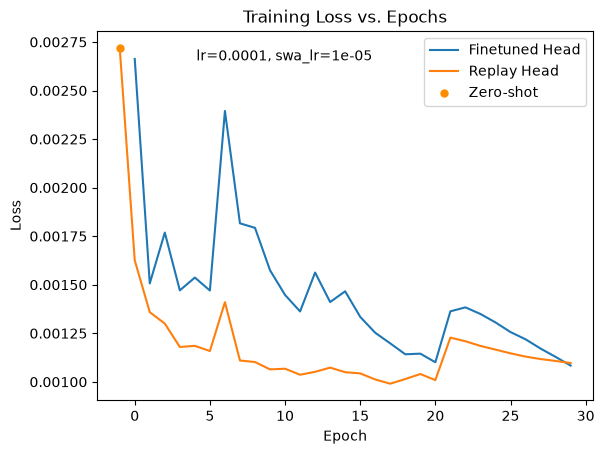

In [28]:
# remove meaningless initial point of tuned head
df_default_plot = df_default[df_default["epoch"] != -1]

# plot loss curves
plt.plot(df_default_plot["epoch"], df_default_plot["loss"], label="Finetuned Head")
plt.plot(df_pt["epoch"], df_pt["loss"], label="Replay Head")

# plot initial guess (zero-shot)
plt.scatter(
    df_pt["epoch"].iloc[0],
    df_pt["loss"].iloc[0],
    marker=".", s=100, color="darkorange", zorder=5, label="Zero-shot"
)

# print learning rates
plt.text(
    0.2, 0.95,
    f"lr={lr}, swa_lr={swa_lr}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
)

plt.title("Training Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

print(f"lr: {lr}, swa_lr: {swa_lr}")

Graph RMSE

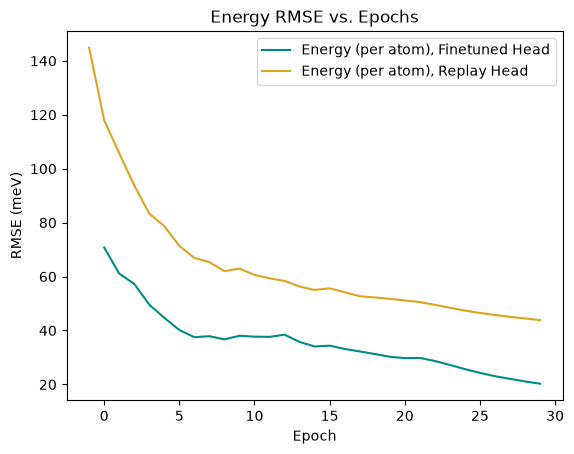

In [29]:
# plot energy RMSEs
plt.plot(df_default_plot["epoch"], df_default_plot["RMSE_E_per_atom"], label="Energy (per atom), Finetuned Head", color="darkcyan")

plt.plot(df_pt["epoch"], df_pt["RMSE_E_per_atom"], label="Energy (per atom), Replay Head", color="goldenrod")


plt.title("Energy RMSE vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("RMSE (meV)")
plt.legend()

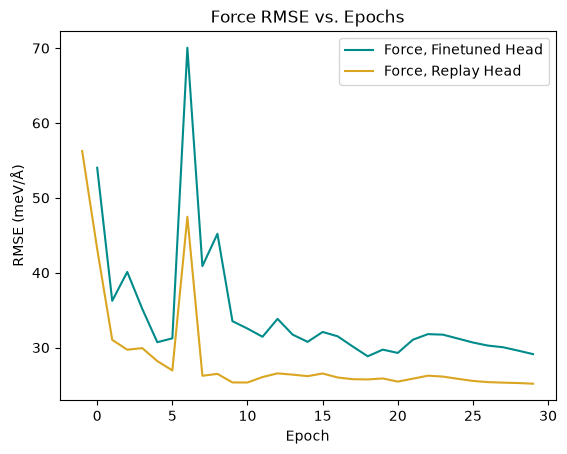

In [30]:
# plot force RMSEs
plt.plot(df_default_plot["epoch"], df_default_plot["RMSE_F"], label="Force, Finetuned Head", color="darkcyan")

plt.plot(df_pt["epoch"], df_pt["RMSE_F"], label="Force, Replay Head", color="goldenrod")

plt.title("Force RMSE vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("RMSE (meV/Å)")
plt.legend()

In [31]:
print(df_default)
print(df_pt)

    epoch     head      loss  RMSE_E_per_atom  RMSE_F  RMSE_stress
1      -1  Default  0.000107           107.57    0.00         0.00
3       0  Default  0.002663            70.77   54.02         5.78
5       1  Default  0.001507            61.08   36.25         8.88
7       2  Default  0.001768            57.28   40.11         8.38
9       3  Default  0.001471            49.58   35.17        10.32
11      4  Default  0.001537            44.71   30.72         9.78
13      5  Default  0.001470            40.17   31.24         9.43
15      6  Default  0.002395            37.52   70.06         8.60
17      7  Default  0.001816            37.89   40.89         8.89
19      8  Default  0.001793            36.70   45.20         8.41
21      9  Default  0.001575            38.05   33.53         9.30
23     10  Default  0.001447            37.71   32.54        10.28
25     11  Default  0.001362            37.63   31.45        10.09
27     12  Default  0.001563            38.45   33.84        1

### Notes

**run_731507**
Zero-shot: for pt_head (the replay head) @ epoch 0, RMSE_E_per_atom: 105.68, RMSE_F: 54.28

**run_731457**

Loss curves indicate
* Catastrophic forgetting: finetuned loss jumps far above replay at the end
 
3 main issues:
1. massive jump in loss from epoch 20 --> 21. to me, this indicates an issue with how SWA is being set/used
2. post-SWA doesn't have enough epochs to potentially converge. 30 is not many epochs, but the finetuning docs said this should converge in 10-30 epochs
3. we didn't really seem to use the first 20 epochs well? loss decreases for the first 5 epochs but then kind of levels off and skips around. the finetune head has min loss around epoch 6, and the replay head hits a min loss around epochs 6 and 20

default lr=0.01, our lr=0.0005
default swa_lr=0.001, our swa_lr=default

On learning rate:  
b/c we have a small dataset (compared to what the literature uses for finetuning MACE), i decreased the lr. smaller corpus --> fewer samples per batch --> noisier\* gradient estimates --> large step size overshoots local minima 

however, swa<=lr, usually set swa = lr/(10-100) 
looking back, finetuning lr=0.0001 in some lit., so lower that as well

\* (higher variance in estimate of "true" gradient, the gradient of loss computed over the entire dataset)